## 1.1 Data Fields

In [35]:
import pandas as pd

df = pd.read_csv('logbook_assignment1.csv', low_memory=False)
print(f"Initial rows: {len(df)}")
print("="*60)

Initial rows: 1174870


#### 1.1.1 Percentage of date_fueled entries that are not proper dates

In [36]:
parsed_dates = pd.to_datetime(df['date_fueled'], format='%b %d %Y', errors='coerce')
invalid_count = parsed_dates.isna().sum()
invalid_pct = (invalid_count / len(df)) * 100
print(f"Invalid/missing date_fueled entries: {invalid_count} ({invalid_pct:.2f}%)")
print("="*60)

Invalid/missing date_fueled entries: 137198 (11.68%)


#### 1.1.2 Where date_fueled is invalid but date_captured is valid, use date_captured as a proxy

In [37]:
parsed_captured = pd.to_datetime(df['date_captured'], format='%b %d %Y', errors='coerce')
needs_proxy = parsed_dates.isna() & parsed_captured.notna()
print(f"Rows filled using date_captured as proxy: {needs_proxy.sum()}")
parsed_dates.loc[needs_proxy] = parsed_captured.loc[needs_proxy]
print(f"Remaining missing after proxy fill: {parsed_dates.isna().sum()}")
print("="*60)

Rows filled using date_captured as proxy: 137198
Remaining missing after proxy fill: 0


#### 1.1.3 Convert the column to a date format and assign the cleaned column back

In [38]:
df['date_fueled'] = parsed_dates
df['date_captured'] = parsed_captured
print(f"date_fueled dtype: {df['date_fueled'].dtype}")
print(f"Missing date_fueled after proxy fill: {df['date_fueled'].isna().sum()}")
print("="*60)

date_fueled dtype: datetime64[us]
Missing date_fueled after proxy fill: 0


#### 1.1.4 Remove dates in the future or earlier than 2005

In [39]:
today = pd.Timestamp.today()
before_count = len(df)

out_of_range = (df['date_fueled'] > today) | (df['date_fueled'] < pd.Timestamp('2005-01-01'))
print(f"Rows with out-of-range dates: {out_of_range.sum()}")

df = df[~out_of_range]
print(f"Rows before: {before_count}, after: {len(df)}, removed: {before_count - len(df)}")
print("="*60)

Rows with out-of-range dates: 582
Rows before: 1174870, after: 1174288, removed: 582


### Plot the distribution of fueling dates

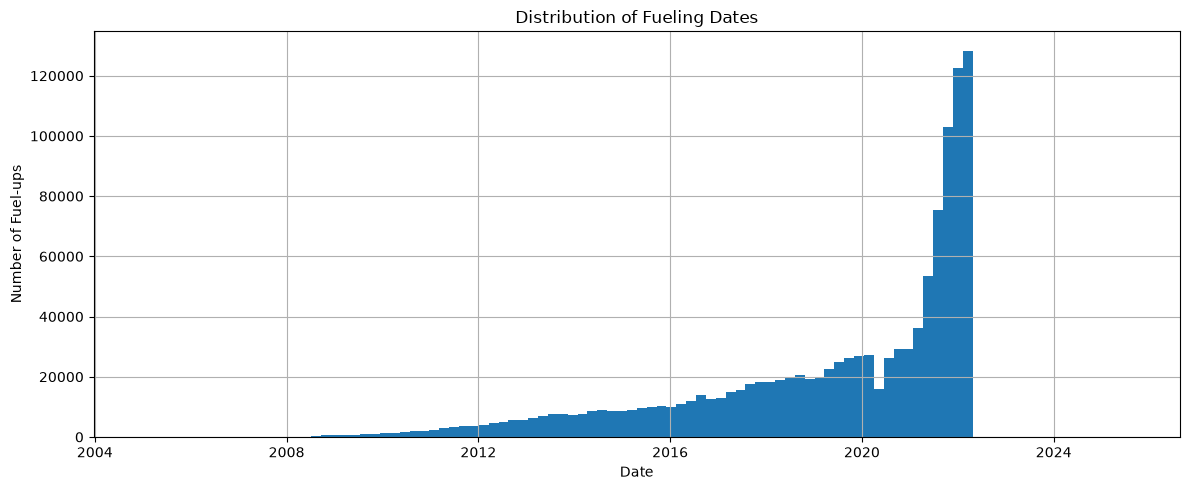

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
df['date_fueled'].dropna().hist(bins=100, ax=ax)
ax.set_title('Distribution of Fueling Dates')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Fuel-ups')
plt.tight_layout()
plt.show()

## 1.2 Numeric Fields
#### 1.2.1 Missing % on raw gallons/miles/odometer, before conversion

In [41]:
total_rows = len(df)
print("before conversion:")
for col in ['gallons', 'miles', 'odometer']:
    missing = df[col].isna().sum()
    pct = (missing / total_rows) * 100
    print(f"  {col}: {missing} missing ({pct:.2f}%)")
print("="*60)

before conversion:
  gallons: 74166 missing (6.32%)
  miles: 1028131 missing (87.55%)
  odometer: 149037 missing (12.69%)


#### 1.2.3 Convert to float (strip commas/whitespace first)

In [42]:
numeric_cols = ['gallons', 'miles', 'odometer', 'mpg']
for col in numeric_cols:
    df[col] = (
        df[col].astype(str)
        .str.strip()
        .str.replace(',', '', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f"dtypes after conversion:\n{df[numeric_cols].dtypes}")
print("="*60)

dtypes after conversion:
gallons     float64
miles       float64
odometer    float64
mpg         float64
dtype: object


### Missing % after conversion

In [43]:
print("after conversion:")
for col in ['gallons', 'miles', 'odometer']:
    missing = df[col].isna().sum()
    pct = (missing / total_rows) * 100
    print(f"{col}: {missing} missing ({pct:.2f}%)")
print("="*60)

after conversion:
gallons: 74166 missing (6.32%)
miles: 1028131 missing (87.55%)
odometer: 149037 missing (12.69%)


#### 1.2.2 Fill missing values using miles/gallons/mpg interdependency

In [44]:
before = {col: df[col].isna().sum() for col in ['gallons', 'miles', 'mpg']}

can_fill_miles = df['miles'].isna() & df['gallons'].notna() & df['mpg'].notna()
df.loc[can_fill_miles, 'miles'] = df.loc[can_fill_miles, 'gallons'] * df.loc[can_fill_miles, 'mpg']

can_fill_gallons = df['gallons'].isna() & df['miles'].notna() & df['mpg'].notna() & (df['mpg'] != 0)
df.loc[can_fill_gallons, 'gallons'] = df.loc[can_fill_gallons, 'miles'] / df.loc[can_fill_gallons, 'mpg']

can_fill_mpg = df['mpg'].isna() & df['miles'].notna() & df['gallons'].notna() & (df['gallons'] != 0)
df.loc[can_fill_mpg, 'mpg'] = df.loc[can_fill_mpg, 'miles'] / df.loc[can_fill_mpg, 'gallons']

after = {col: df[col].isna().sum() for col in ['gallons', 'miles', 'mpg']}

print("Interdependency fill results:")
for col in ['gallons', 'miles', 'mpg']:
    filled = before[col] - after[col]
    print(f"{col}: filled {filled} values ({before[col]} -> {after[col]} missing)")
print("="*60)

Interdependency fill results:
gallons: filled 0 values (74166 -> 74166 missing)
miles: filled 953965 values (1028131 -> 74166 missing)
mpg: filled 0 values (74166 -> 74166 missing)


### Plot distributions

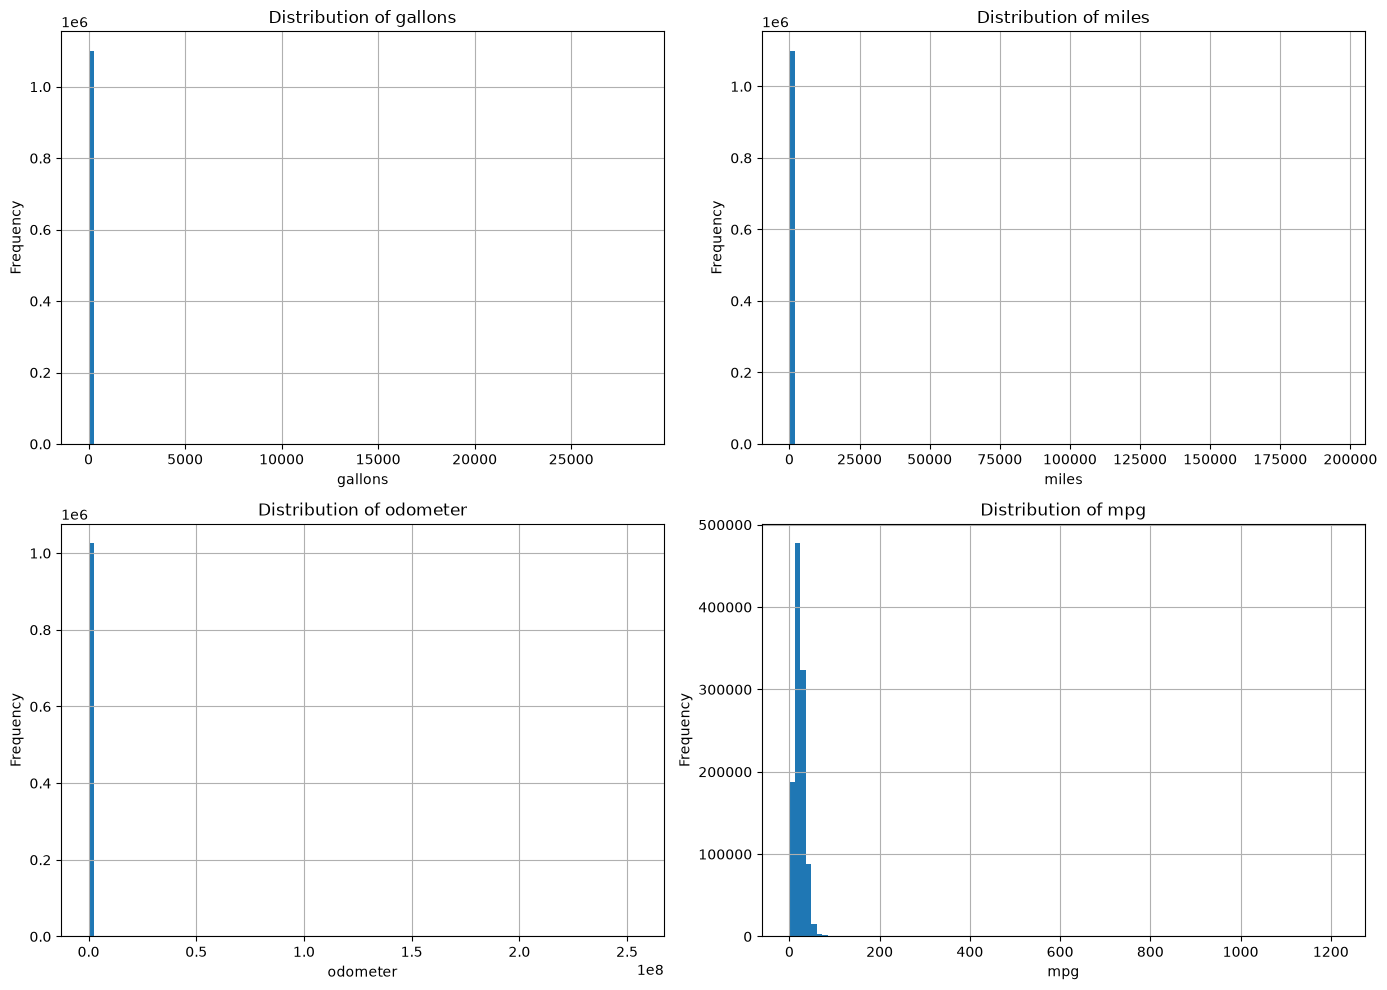

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['gallons', 'miles', 'odometer', 'mpg']):
    df[col].dropna().hist(bins=100, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Statistical description

In [46]:
stats_cols = ['gallons', 'miles', 'odometer', 'mpg']
desc = df[stats_cols].describe()
modes = df[stats_cols].mode().iloc[0]
desc.loc['mode'] = modes
print("Statistical description")
print(desc)

Statistical description
            gallons         miles      odometer           mpg
count  1.100122e+06  1.100122e+06  1.025251e+06  1.100122e+06
mean   1.279740e+01  2.694538e+02  1.040006e+05  2.216306e+01
std    7.448303e+01  7.257657e+02  3.405995e+05  1.574439e+01
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
25%    8.990000e+00  1.814000e+02  4.592400e+04  1.560000e+01
50%    1.195400e+01  2.670483e+02  9.188700e+04  2.180000e+01
75%    1.493900e+01  3.427648e+02  1.469240e+05  2.850000e+01
max    2.838000e+04  1.953212e+05  2.543621e+08  1.214300e+03
mode   1.056700e+01  0.000000e+00  1.000000e+00  0.000000e+00


### Converting the rest for memory's sake

In [47]:
#cost_per_gallon / total_spent: left as strings for now
print(f"cost_per_gallon dtype: {df['cost_per_gallon'].dtype}")
print(f"total_spent dtype:     {df['total_spent'].dtype}")
print("="*60)

#Downcast already-numeric measurement columns to float32
float_cols = ['odometer', 'miles', 'gallons', 'mpg']
print(f"Memory before float32 downcast: {df[float_cols].memory_usage(deep=True).sum() / 1024**2:.2f} MB")
for col in float_cols:
    df[col] = df[col].astype('float32')
print(f"Memory after float32 downcast:  {df[float_cols].memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("="*60)

#user_url as categorical
print(f"BEFORE user_url conversion: memory = {df['user_url'].memory_usage(deep=True) / 1024**2:.2f} MB")
df['user_url'] = df['user_url'].astype('category')
print(f"AFTER user_url conversion:  memory = {df['user_url'].memory_usage(deep=True) / 1024**2:.2f} MB")
print("="*60)

#Final summary
print(f"\nFINAL dtypes:\n{df.dtypes}")
print(f"\nFINAL missing values:\n{df.isna().sum()}")
print(f"\nFINAL total memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

cost_per_gallon dtype: str
total_spent dtype:     str
Memory before float32 downcast: 44.80 MB
Memory after float32 downcast:  26.88 MB
BEFORE user_url conversion: memory = 123.44 MB
AFTER user_url conversion:  memory = 25.16 MB

FINAL dtypes:
date_fueled        datetime64[us]
date_captured      datetime64[us]
odometer                  float32
gallons                   float32
cost_per_gallon               str
total_spent                   str
mpg                       float32
miles                     float32
user_url                 category
dtype: object

FINAL missing values:
date_fueled             0
date_captured           0
odometer           149037
gallons             74166
cost_per_gallon     80714
total_spent         74166
mpg                 74166
miles               74166
user_url                0
dtype: int64

FINAL total memory: 187.63 MB


#### 2.1.1 Create a new column with the currency.
#### 2.1.2 Extracting currency and cost per gallon

In [48]:
for col in ['cost_per_gallon', 'total_spent']:
    extracted = df[col].astype(str).str.extract(r'^([^\d]*)([\d,]+\.?\d*)')
    
    currency = extracted[0].str.strip()
    currency = currency.replace('', pd.NA)   # empty string -> NaN, not a currency
    
    amount = extracted[1].str.replace(',', '', regex=False)
    amount = pd.to_numeric(amount, errors='coerce')
    
    df[f'{col}_currency'] = currency.astype('category')
    df[f'{col}_value'] = amount.astype('float32')

print(df[['cost_per_gallon', 'cost_per_gallon_currency', 'cost_per_gallon_value',
          'total_spent', 'total_spent_currency', 'total_spent_value']].head(10))
print("="*60)

  cost_per_gallon cost_per_gallon_currency  cost_per_gallon_value total_spent  \
0             NaN                      NaN                    NaN         NaN   
1          $5.599                        $                  5.599      $67.86   
2           £5.45                        £                  5.450      £43.53   
3           £5.11                        £                  5.110      £54.00   
4          $3.029                        $                  3.029      $35.29   
5          $3.739                        $                  3.739      $12.76   
6          $4.639                        $                  4.639      $41.96   
7          $2.929                        $                  2.929      $43.82   
8             NaN                      NaN                    NaN         NaN   
9          $1.999                        $                  1.999       $5.42   

  total_spent_currency  total_spent_value  
0                  NaN                NaN  
1                   

#### 2.1.3 Extract car_make, car_model, car_year, user_id

In [49]:
url_parts = df['user_url'].astype(str).str.rstrip('/').str.split('/')
seg_count = url_parts.str.len()

df['car_make'] = pd.NA
df['car_model'] = pd.NA
df['car_year'] = pd.NA
df['user_id'] = pd.NA

#7-segment: make/model/year/id 
standard = seg_count == 7
df.loc[standard, 'car_make'] = url_parts[standard].str[-4]
df.loc[standard, 'car_model'] = url_parts[standard].str[-3]
df.loc[standard, 'car_year'] = url_parts[standard].str[-2]
df.loc[standard, 'user_id'] = url_parts[standard].str[-1]

#6-segment: make/model/id, (year missing) — first segment must be a known make
known_makes = set(url_parts[standard].str[-4].unique())
six_seg = seg_count == 6
first_seg = url_parts[six_seg].str[-3]
pattern_a = first_seg.isin(known_makes)

six_idx = df.loc[six_seg].index[pattern_a.values]
df.loc[six_idx, 'car_make'] = url_parts.loc[six_idx].str[-3]
df.loc[six_idx, 'car_model'] = url_parts.loc[six_idx].str[-2]
df.loc[six_idx, 'car_year'] = pd.NA
df.loc[six_idx, 'user_id'] = url_parts.loc[six_idx].str[-1]

#Everything else (6-seg Pattern B, 8-seg, any other odd structure) stays NaN — left unparsed

df['car_year'] = pd.to_numeric(df['car_year'], errors='coerce')
df['car_make'] = df['car_make'].astype('category')
df['car_model'] = df['car_model'].astype('category')

print(f"car_make missing: {df['car_make'].isna().sum()}")
print(f"car_model missing: {df['car_model'].isna().sum()}")
print(f"car_year missing: {df['car_year'].isna().sum()}")
print(f"user_id missing: {df['user_id'].isna().sum()}")
print(f"\nRows left fully unparsed (not standard, not Pattern A): {(~standard & ~six_seg.map(lambda x: False)).sum() if False else 'see below'}")

unparsed = df['car_make'].isna() & df['car_model'].isna()
print(f"Rows with make AND model both missing: {unparsed.sum()}")

car_make missing: 1216
car_model missing: 1216
car_year missing: 5062
user_id missing: 1216

Rows left fully unparsed (not standard, not Pattern A): see below
Rows with make AND model both missing: 1216


Notes here: 
I first got this:

- car_make missing: 0
- car_model missing: 0
- car_year missing: 3737
- user_id missing: 0

Rows with missing car_year: 3737

user_url
- auris               59
- cx-9                50
- accord              50
- odyssey             50
- 4runner             49
- pathfinder          47
- civic               42
- optima              41
- picanto             38
- wrangler            38
- f-350_super_duty    35
- matrix              34
- hilux               34
- tundra              33
- santa_fe            32
- corolla             31
- e320                31
- e-350_super_duty    31
- x3                  30
- pajero              30

Then I looked at URL Structure:

Segment count distribution:
user_url
- 7 = 1169238
- 6 = 4732
- 8 = 330

Segment count specifically for year-missing rows:
user_url
- 6 = 3737

These were the bad guys:
['https://www.somewebsite.com/kianival/2009/789684', 'https://www.somewebsite.com/kiaens/2012/511793', 'https://www.somewebsite.com/fiat/multipla/10363', 'https://www.somewebsite.com/land_rover/defender_90/841556', 'https://www.somewebsite.com/subaru/wrx_sti/680817', 'https://www.somewebsite.com/kianival/2007/801710', 'https://www.somewebsite.com/audi/q5/1000137', 'https://www.somewebsite.com/kiaens/2009/1025974', 'https://www.somewebsite.com/kianival/2006/80567', 'https://www.somewebsite.com/kianival/2009/789684', 'https://www.somewebsite.com/ford/explorer/193105', 'https://www.somewebsite.com/volkswagen/transporter/762428', 'https://www.somewebsite.com/toyota/yaris/1120723', 'https://www.somewebsite.com/volkswagen/transporter/762428', 'https://www.somewebsite.com/mercedes-benz/c250/686102', 'https://www.somewebsite.com/volkswagenavelle/1996/491811', 'https://www.somewebsite.com/nissan/versa/762979', 'https://www.somewebsite.com/honda/beat/572686', 'https://www.somewebsite.com/bmw/335i_xdrive/1053763', 'https://www.somewebsite.com/jeep/cj7/490985']

So
- Pattern A: make/model/id
- Pattern B: makemodel/year/id

I could extract pattern A. Pattarn B is too difficult

## 2.2 
#### 2.2.1 Litres filled

In [50]:
US_GALLON_TO_LITRES = 3.78541

df['litres_filled'] = (df['gallons'] * US_GALLON_TO_LITRES).astype('float32')

print(f"litres_filled missing: {df['litres_filled'].isna().sum()}")
print(df[['gallons', 'litres_filled']].head(10))
print("="*60)

litres_filled missing: 74166
   gallons  litres_filled
0      NaN            NaN
1   12.120      45.879169
2    7.991      30.249212
3   10.575      40.030708
4   11.651      44.103809
5    3.413      12.919604
6    9.044      34.235245
7   14.962      56.637302
8      NaN            NaN
9    2.710      10.258461


I went with US as they have the most users

#### 2.2.2 km driven

In [51]:
MILES_TO_KM = 1.60934

df['km_driven'] = (df['miles'] * MILES_TO_KM).astype('float32')

print(f"km_driven missing: {df['km_driven'].isna().sum()}")
print(df[['miles', 'km_driven']].head(10))
print("="*60)

km_driven missing: 74166
        miles   km_driven
0         NaN         NaN
1  382.992004  616.364319
2  227.743500  366.516724
3  494.910004  796.478455
4  244.399994  393.322662
5   98.976997  159.287643
6  266.798004  429.368683
7  408.462585  657.355164
8         NaN         NaN
9    0.000000    0.000000


#### 2.2.3 litres/100km

In [52]:
valid_km = df['km_driven'].notna() & (df['km_driven'] != 0)

df['litres_per_100km'] = pd.NA
df.loc[valid_km, 'litres_per_100km'] = (
    df.loc[valid_km, 'litres_filled'] / df.loc[valid_km, 'km_driven'] * 100
)
df['litres_per_100km'] = pd.to_numeric(df['litres_per_100km'], errors='coerce').astype('float32')

print(f"litres_per_100km missing: {df['litres_per_100km'].isna().sum()}")
print(df[['litres_filled', 'km_driven', 'litres_per_100km']].head(10))
print("="*60)


litres_per_100km missing: 208916
   litres_filled   km_driven  litres_per_100km
0            NaN         NaN               NaN
1      45.879169  616.364319          7.443514
2      30.249212  366.516724          8.253160
3      40.030708  796.478455          5.025962
4      44.103809  393.322662         11.213138
5      12.919604  159.287643          8.110865
6      34.235245  429.368683          7.973392
7      56.637302  657.355164          8.615936
8            NaN         NaN               NaN
9      10.258461    0.000000               NaN


These missing values are interesting and worth looking into

In [53]:
print(df[['litres_filled', 'km_driven', 'litres_per_100km']].describe())

       litres_filled     km_driven  litres_per_100km
count   1.100122e+06  1.100122e+06     965372.000000
mean    4.844340e+01  4.336427e+02         12.170321
std     2.819488e+02  1.168004e+03         47.976692
min     0.000000e+00  0.000000e+00          0.000000
25%     3.403083e+01  2.919343e+02          7.893123
50%     4.525079e+01  4.297715e+02         10.095067
75%     5.655024e+01  5.516251e+02         12.923905
max     1.074299e+05  3.143382e+05      12426.411133


## 3. Vehicle Exploration
#### 3.1 Unique users per country

Top 20 currencies by unique users:
total_spent_currency
$      78666
£      10834
€       6738
CA$     5073
R       4032
AU$     2589
NZ$      989
RM       989
R$       706
Skr      566
zł       565
Rs       533
₱        478
฿        442
Dkr      427
Ft       414
RUB      395
MXN      388
Nkr      350
BGN      339
Name: user_id, dtype: int64


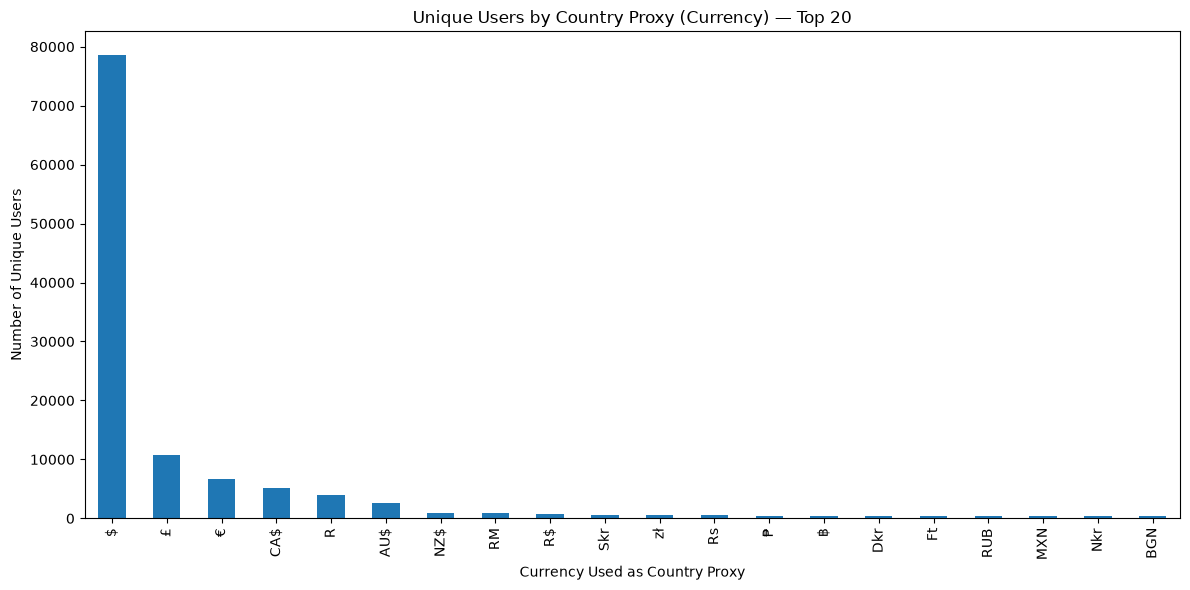

In [66]:
users_per_currency = df.groupby('total_spent_currency', observed=True)['user_id'].nunique().sort_values(ascending=False)

print("Top 20 currencies by unique users:")
print(users_per_currency.head(20))

fig, ax = plt.subplots(figsize=(12, 6))
users_per_currency.head(20).plot(kind='bar', ax=ax)
# ax.set_title('Unique Users per Currency (Top 20)')
ax.set_title('Unique Users by Country Proxy (Currency) — Top 20')
# ax.set_xlabel('Currency')
ax.set_xlabel('Currency Used as Country Proxy')
ax.set_ylabel('Number of Unique Users')
plt.tight_layout()
plt.show()

#### 3.2 Unique users per day

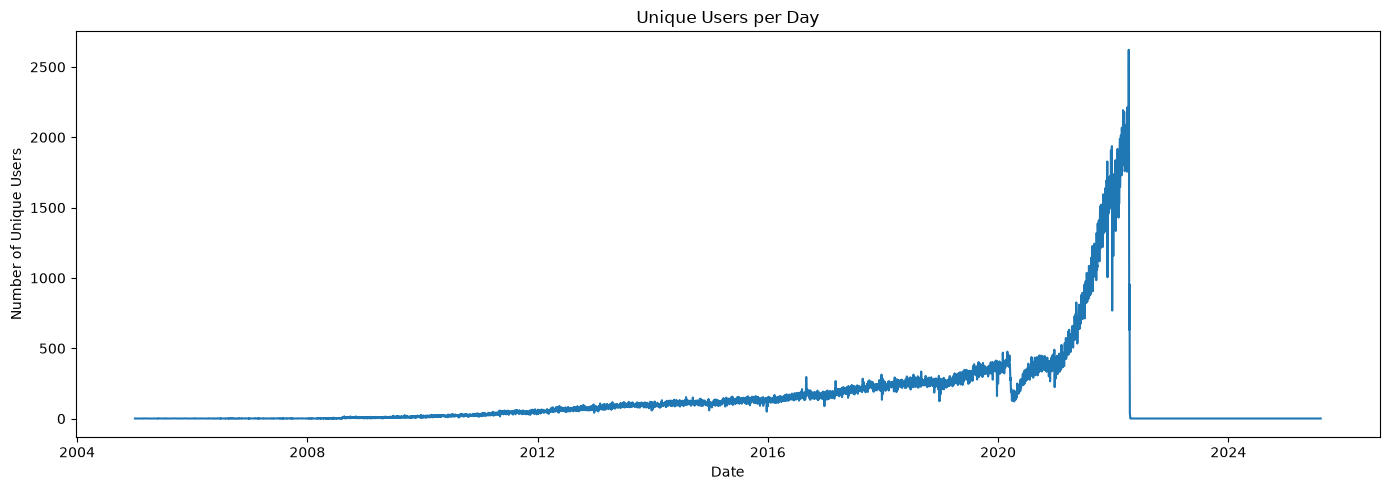

In [67]:
users_per_day = df.groupby(df['date_fueled'].dt.date)['user_id'].nunique()

fig, ax = plt.subplots(figsize=(14, 5))
users_per_day.plot(ax=ax)
ax.set_title('Unique Users per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Unique Users')
plt.tight_layout()
plt.show()

This looks fishy. Why does it just drop off?

#### 3.3 Vehicle age

vehicle_age missing: 5062
count    1.169226e+06
mean     1.112643e+01
std      8.343314e+00
min     -9.000000e+00
25%      5.000000e+00
50%      1.000000e+01
75%      1.600000e+01
max      1.030000e+02
Name: vehicle_age, dtype: float64


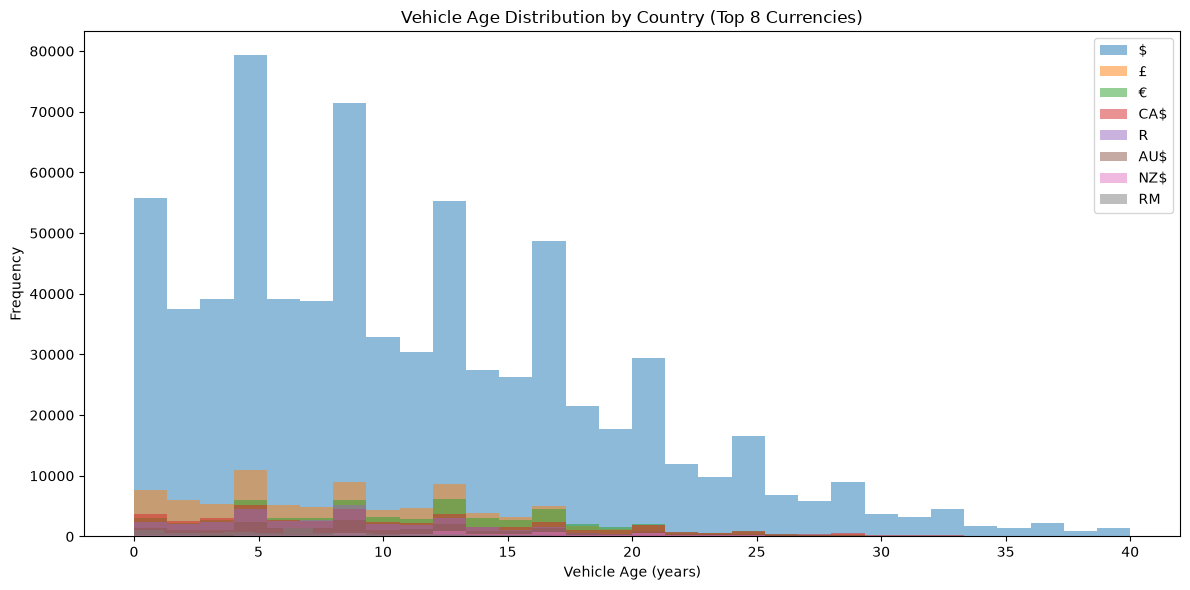

In [56]:
df['vehicle_age'] = df['date_fueled'].dt.year - df['car_year']

print(f"vehicle_age missing: {df['vehicle_age'].isna().sum()}")
print(df['vehicle_age'].describe())

# Focus on top currencies by user count for a readable plot
top_currencies = users_per_currency.head(8).index

fig, ax = plt.subplots(figsize=(12, 6))
for cur in top_currencies:
    subset = df.loc[df['total_spent_currency'] == cur, 'vehicle_age'].dropna()
    subset = subset[(subset >= 0) & (subset <= 40)]  # sanity bound to remove clearly bad values
    ax.hist(subset, bins=30, alpha=0.5, label=str(cur))

ax.set_title('Vehicle Age Distribution by Country (Top 8 Currencies)')
ax.set_xlabel('Vehicle Age (years)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

#### 3.4 Most popular makes and models

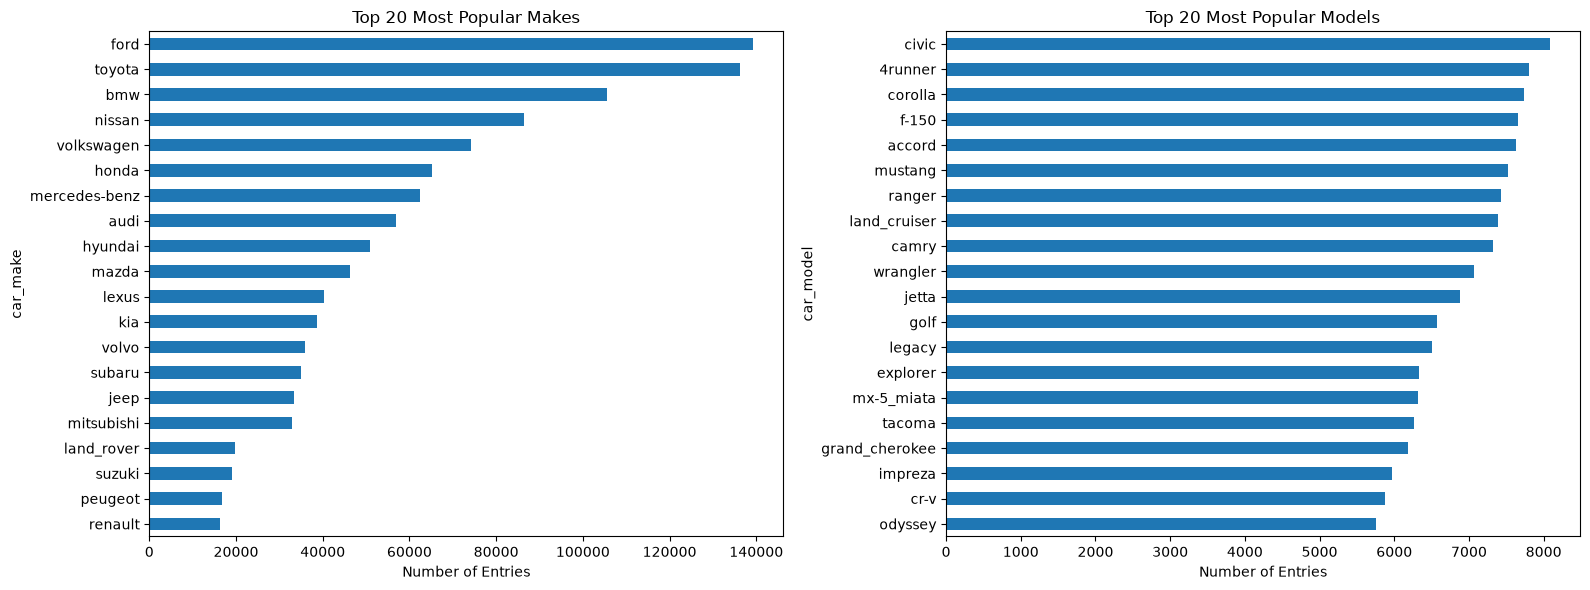

Top makes:
car_make
ford             139248
toyota           136202
bmw              105479
nissan            86512
volkswagen        74216
honda             65312
mercedes-benz     62458
audi              56925
hyundai           50796
mazda             46371
lexus             40278
kia               38777
volvo             35908
subaru            34910
jeep              33483
mitsubishi        32829
land_rover        19696
suzuki            19123
peugeot           16741
renault           16294
Name: count, dtype: int64

Top models:
car_model
civic             8082
4runner           7810
corolla           7737
f-150             7661
accord            7633
mustang           7520
ranger            7424
land_cruiser      7388
camry             7316
wrangler          7061
jetta             6882
golf              6576
legacy            6501
explorer          6336
mx-5_miata        6324
tacoma            6260
grand_cherokee    6181
impreza           5975
cr-v              5876
odyssey       

In [57]:
make_counts = df['car_make'].value_counts().head(20)
model_counts = df['car_model'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

make_counts.plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 20 Most Popular Makes')
axes[0].set_xlabel('Number of Entries')
axes[0].invert_yaxis()

model_counts.plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 20 Most Popular Models')
axes[1].set_xlabel('Number of Entries')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Top makes:")
print(make_counts)
print("\nTop models:")
print(model_counts)

## Question 4.1: Outlier Removal 

#### 4.1.1: Top 5 currencies by number of transactions 

In [58]:
currency_transaction_count = (df['total_spent_currency'].value_counts())

top_5 = currency_transaction_count.head(5)
top_5_list = top_5.index.tolist()

print("Top 5 currencies by number of transactions:")
print(top_5)

Top 5 currencies by number of transactions:
total_spent_currency
$      741946
£       87587
€       59273
CA$     46848
R       36424
Name: count, dtype: int64


#### 4.1.2: Removing outliers 

In [59]:
df_top5 = df[df['total_spent_currency'].isin(top_5_list)].copy()

print(f"Rows in complete dataset: {len(df):,}")
print(f"Rows in top-five currencies: {len(df_top5):,}")
print(f"Top-five currencies: {top_5_list}")


Rows in complete dataset: 1,174,288
Rows in top-five currencies: 972,078
Top-five currencies: ['$', '£', '€', 'CA$', 'R']


In [60]:
US_GALLON_TO_LITRES = 3.78541

valid_recorded_price = (
    df_top5['cost_per_gallon_value'].notna()
    & (df_top5['cost_per_gallon_value'] > 0)
)

df_top5['cost_per_litre'] = pd.NA
df_top5.loc[valid_recorded_price, 'cost_per_litre'] = (
    df_top5.loc[valid_recorded_price, 'cost_per_gallon_value'] / US_GALLON_TO_LITRES
)
df_top5['cost_per_litre'] = pd.to_numeric(df_top5['cost_per_litre'], errors='coerce')

print(f"cost_per_litre missing: {df_top5['cost_per_litre'].isna().sum():,} of {len(df_top5):,}")

cost_per_litre missing: 11,975 of 972,078


In [61]:
currency_limits = {
    '$':   {'min_cost_per_litre': 0.30, 'max_cost_per_litre': 3.00, 'max_total_spent': 1000},
    '£':   {'min_cost_per_litre': 0.40, 'max_cost_per_litre': 3.00, 'max_total_spent': 500},
    '€':   {'min_cost_per_litre': 0.40, 'max_cost_per_litre': 3.50, 'max_total_spent': 500},
    'CA$': {'min_cost_per_litre': 0.40, 'max_cost_per_litre': 3.00, 'max_total_spent': 600},
    'R':   {'min_cost_per_litre': 3.00, 'max_cost_per_litre': 30.00, 'max_total_spent': 7500},
}

In [62]:
flags = pd.DataFrame(False, index=df_top5.index, columns=[
    'nonpositive_litres', 'over_250_litres',
    'efficiency_below_2', 'efficiency_above_50',
    'zero_cost_per_gallon', 'zero_total_spent',
    'cost_per_litre_out_of_range', 'total_spent_too_high'
])

flags['nonpositive_litres']   = df_top5['litres_filled'].notna() & (df_top5['litres_filled'] <= 0)
flags['over_250_litres']      = df_top5['litres_filled'] > 250
flags['efficiency_below_2']   = df_top5['litres_per_100km'].notna() & (df_top5['litres_per_100km'] < 2)
flags['efficiency_above_50']  = df_top5['litres_per_100km'] > 50
flags['zero_cost_per_gallon'] = df_top5['cost_per_gallon_value'] == 0
flags['zero_total_spent']     = df_top5['total_spent_value'] == 0

for currency, limits in currency_limits.items():
    rows = df_top5['total_spent_currency'] == currency

    out_of_price_range = df_top5['cost_per_litre'].notna() & (
        (df_top5['cost_per_litre'] < limits['min_cost_per_litre']) |
        (df_top5['cost_per_litre'] > limits['max_cost_per_litre'])
    )
    flags.loc[rows & out_of_price_range, 'cost_per_litre_out_of_range'] = True

    too_high = df_top5['total_spent_value'].notna() & (df_top5['total_spent_value'] > limits['max_total_spent'])
    flags.loc[rows & too_high, 'total_spent_too_high'] = True

is_outlier = flags.any(axis=1)

print("Rule trigger counts:")
print(flags.sum())
print(f"\nTotal flagged: {is_outlier.sum():,} of {len(df_top5):,} ({is_outlier.mean()*100:.2f}%)")

Rule trigger counts:
nonpositive_litres               521
over_250_litres                  771
efficiency_below_2              2391
efficiency_above_50             3002
zero_cost_per_gallon            6834
zero_total_spent               12005
cost_per_litre_out_of_range    43552
total_spent_too_high           15448
dtype: int64

Total flagged: 60,543 of 972,078 (6.23%)


In [63]:
summary = pd.DataFrame({
    'currency': df_top5['total_spent_currency'],
    'is_outlier': is_outlier
}).groupby('currency', observed=True).agg(
    total=('is_outlier', 'size'),
    flagged=('is_outlier', 'sum')
).loc[list(currency_limits.keys())]

summary['pct_flagged'] = (summary['flagged'] / summary['total'] * 100).round(2)
summary

,total,flagged,pct_flagged
currency,,,
$,741946,50770,6.84
£,87587,4240,4.84
€,59273,2587,4.36
CA$,46848,1578,3.37
R,36424,1368,3.76


In [64]:
df_top5[
    (df_top5['total_spent_currency'] == 'R') &
    (df_top5['cost_per_litre'] > currency_limits['R']['max_cost_per_litre'])
].nsmallest(5, 'cost_per_litre')[
    ['date_fueled', 'cost_per_litre', 'total_spent_value', 'litres_filled', 'car_make']
]

,date_fueled,cost_per_litre,total_spent_value,litres_filled,car_make
411654,2014-06-11,31.830105,1197.430054,37.619404,mercedes-benz
322246,2020-09-06,32.715080,473.709991,14.479193,mazda
485376,2021-12-03,33.349094,1112.219971,33.349464,ford
867681,2021-08-30,33.732147,2035.280029,60.335648,nissan
884830,2018-11-14,34.749207,2094.229980,60.267509,volkswagen


#### 4.1.3: Number of Transactions Removed

In [65]:
before = len(df_top5)
df_clean = df_top5[~is_outlier].copy()
after = len(df_clean)

print(f"Rows before outlier removal: {before:,}")
print(f"Rows after outlier removal:  {after:,}")
print(f"Rows removed: {before - after:,} ({(before - after) / before * 100:.2f}%)")

Rows before outlier removal: 972,078
Rows after outlier removal:  911,535
Rows removed: 60,543 (6.23%)
